In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import matplotlib

# 设置 Windows 中文字体
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
matplotlib.rcParams['axes.unicode_minus'] = False  

# ==== 数据 ====
name="振超"
period="20XX-XX-XX至20XX-XX-XX"
data = """名称	1:00	2:00	3:00	4:00	5:00	6:00	7:00	8:00	9:00	10:00	11:00	12:00	13:00	14:00	15:00	16:00	17:00	18:00	19:00	20:00	21:00	22:00	23:00	24:00
Q中长期	59.886	67.165	65.997	65.993	63.443	64.644	53.17	52.536	34.94	36.939	38.939	39.01	27.011	59.082	20.474	20.475	60.625	22.194	22.25	25.94	30.97	35.969	38.58	42.41
Q日前出清	59.531	62.978	64.652	62.803	69.354	68.101	63.441	56.588	41.503	30.592	27.14	23.683	15.768	13.6	14.115	17.186	20.168	20.219	22.573	25.453	33.191	39.098	50.47	59.076
P中长期	240.0584444	241.6891238	244.9062836	244.4775961	191.0508646	174.0328569	179.957871	141.5642607	323.8752147	320.8995912	315.7803231	246.1266342	258.0852245	168.4621374	242.9461756	241.1921856	167.8957526	271.1052537	273.0292135	310.7632999	302.3216015	298.1292224	319.8976153	315.6413582
P日前	42.246	42.039	40.169	41.718	61.287	67.315	63.725	41.169	40	40	40	40	40	40	40	40	40	40	40	40	40	40	40.733	40
"""
df = pd.read_csv(StringIO(data), sep="\t")



In [3]:
df

,名称,1:00,2:00,3:00,4:00,5:00,6:00,7:00,8:00,9:00,...,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00,24:00
0,Q中长期,59.886000,67.165000,65.997000,65.993000,63.443000,64.644000,53.170000,52.536000,34.940000,...,20.474000,20.475000,60.625000,22.194000,22.250000,25.9400,30.970000,35.969000,38.580000,42.410000
1,Q日前出清,59.531000,62.978000,64.652000,62.803000,69.354000,68.101000,63.441000,56.588000,41.503000,...,14.115000,17.186000,20.168000,20.219000,22.573000,25.4530,33.191000,39.098000,50.470000,59.076000
2,P中长期,240.058444,241.689124,244.906284,244.477596,191.050865,174.032857,179.957871,141.564261,323.875215,...,242.946176,241.192186,167.895753,271.105254,273.029214,310.7633,302.321601,298.129222,319.897615,315.641358
3,P日前,42.246000,42.039000,40.169000,41.718000,61.287000,67.315000,63.725000,41.169000,40.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.0000,40.000000,40.000000,40.733000,40.000000


In [10]:
df_t.dtypes

名称
Q中长期     float64
Q日前出清    float64
P中长期     float64
P日前      float64
dtype: object

In [8]:
# 转置方便绘图
df_t = df.set_index("名称").T
hours = df_t.index
hours

Index(['1:00', '2:00', '3:00', '4:00', '5:00', '6:00', '7:00', '8:00', '9:00',
       '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00',
       '18:00', '19:00', '20:00', '21:00', '22:00', '23:00', '24:00'],
      dtype='object')

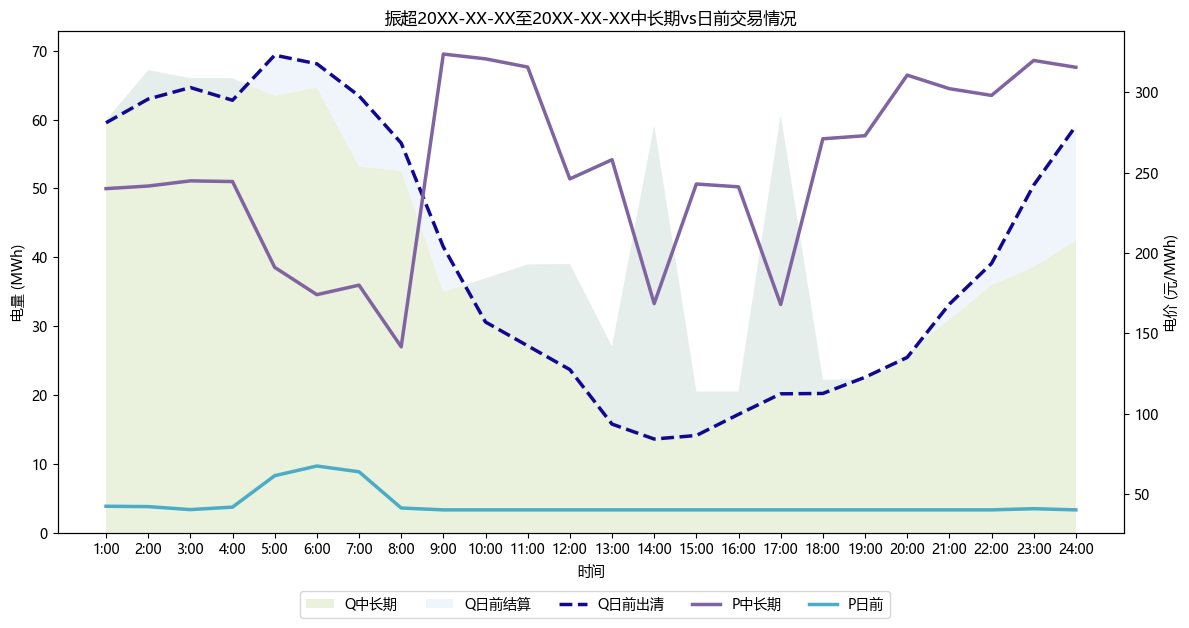

In [2]:

# 创建图表
fig, ax1 = plt.subplots(figsize=(12, 6))

# 面积堆叠图（电量）
ax1.stackplot(hours,
              df_t["Q中长期"],
              df_t["Q日前出清"]-df_t["Q中长期"],
               colors=["#d7e4bd", "#e2ecf8"],  # 天蓝 + 浅绿
              labels=["Q中长期","Q日前结算" ],
              alpha=0.5)
ax1.plot(hours, df_t["Q日前出清"],  label="Q日前出清",linewidth=2.5, color="#110892" , linestyle="--")
ax1.set_ylabel("电量 (MWh)")
ax1.set_xlabel("时间")
# ax1.legend(loc="upper left")

# 第二y轴绘制折线图（电价）
ax2 = ax1.twinx()
ax2.plot(hours, df_t["P中长期"], label="P中长期",  color="#8064a2",linewidth=2.5)
ax2.plot(hours, df_t["P日前"], label="P日前", color="#4bacc6",linewidth=2.5)
ax2.set_ylabel("电价 (元/MWh)")
# ax2.legend(loc="upper right")
# 添加全局图例
fig.legend(loc='lower center',bbox_to_anchor=(0.5, -0.05), ncol=5)  # ncol=2 表示横向排列

plt.title(f"{name}{period}中长期vs日前交易情况")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{name}{period}中长期vs日前交易情况.png", format='png', dpi=300)  # 保存为 PNG 格式
plt.show()